# 통번역과 AI III Midterm Workshop
한국외국어대학교 통번역대학원


Prof. Seungtaek Choi

## 1 구글 드라이브 마운트 설정 및 소스 이미지 확인

### 1.1 구글 드라이브에 공유 폴더 바로가기 만들기

- 해당 공유 폴더 링크에 들어가주세요
https://drive.google.com/drive/folders/1C_vmckfBTH4Axhf9R7ONxKg1lEjgyFAv?usp=sharing

- 좌측 [공유 문서함] -> 해당 [images] 폴더 우클릭 -> [정리] -> [바로가기 추가]

### 1.2 구글 드라이브 마운트 설정 및 이미지 폴더 경로 설정
- 아래 셀의 코드를 실행해주세요
  - 구글 드라이브 마운트란?: 구글 코랩에서 내 계정의 구글 드라이브에 접근할 수 있도록 설정
  - 팝업창이 뜨면 인증을 완료해주세요

In [ ]:
from google.colab import drive
import os

drive.mount("/content/drive")
images = "/content/drive/MyDrive/images"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1.3 실습 이미지 샘플 확인
- 구글 드라이브 마운트 및 폴더 경로 설정이 정상적으로 되었는지 확인하는 과정입니다
- AI 프롬프팅으로 코드를 생성해 아래 셀을 채운 후 실행해주세요
- 프롬프트에는 아래 내용을 포함해주세요
  - 설정해둔 이미지 폴더 경로에 있는 첫 이미지 3개에 대해서 시각화
  - 이미지 파일은 png 형식

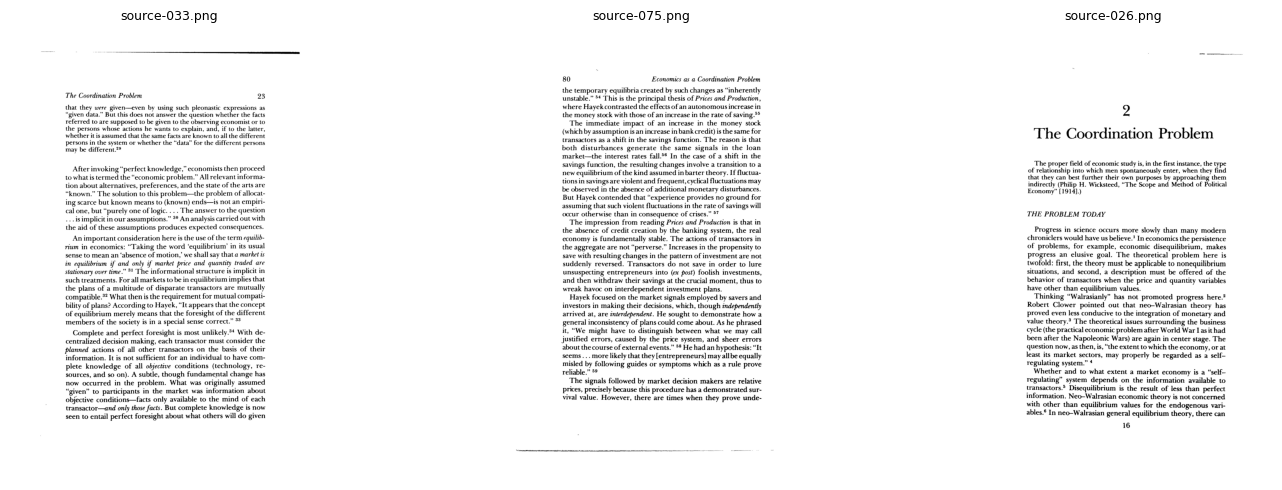

In [ ]:
"""
실습 이미지 샘플 확인 코드
"""

# ===== 예시 (워크샵 당일 삭제) =====

import os
from PIL import Image
import matplotlib.pyplot as plt

png_files = [f for f in os.listdir(images) if f.endswith(".png")][:3]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, fname in zip(axes, png_files):
    img = Image.open(os.path.join(images, fname))
    ax.imshow(img)
    ax.set_title(fname, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 2 OCR 수행하기

### 2.1 GLM-OCR 모델 불러오기

- week 04에 수행했던 실습 내용을 참고하여 빈 코드 셀들을 채워주세요
- 셀 내용에 해당하는 코드를 복사-붙여넣기로 가져온 후 실행해주세요

In [ ]:
"""
패키지 설치 코드: OCR 모델이 실행될 수 있도록 기반 환경을 마련해줌
"""

# ===== 예시 (워크샵 당일 삭제) =====
!pip install git+https://github.com/huggingface/transformers.git
!pip install --upgrade transformers

  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-mexd_9_5
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-mexd_9_5
  Resolved https://github.com/huggingface/transformers.git to commit f3a68c4c187d009504ef140febb3769d56b600f4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for transformers: filename=transformers-5.6.0.dev0-py3-none-any.whl size=11381798 sha256=25458fbcb39a418af269d6caf43720bad606b170e23b63ce1a05c987d0761ff8
  Stored in directory: /tmp/pip-ephem-wheel-cache-4wo58zu4/wheels/54/cb/3f/83103de5575c534436d6a4686686dead458238dfaf1147e98d
Successfully built transformers
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
"""
OCR 모델 불러오기 코드: GLM-OCR 사용
"""

# ===== 예시 (워크샵 당일 삭제) =====
from transformers import AutoProcessor, AutoModelForImageTextToText
import torch

ocr_model_name = "zai-org/GLM-OCR"
ocr_processor = AutoProcessor.from_pretrained(ocr_model_name)
ocr_model = AutoModelForImageTextToText.from_pretrained(
    ocr_model_name,
    torch_dtype=torch.float16,
    device_map="auto",
)
print("GLM-OCR loaded!")

preprocessor_config.json:   0%|          | 0.00/367 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.65G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/510 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/165 [00:00<?, ?B/s]

GLM-OCR loaded!


### 2.2 OCR 수행하기

- step 1: week 04에 수행했던 실습 내용을 참고하여 빈 코드 셀을 채워주세요
  - 실습 때 '신림역 이미지 한개에 대해서만 OCR을 수행하는 코드'와 '폴더 내 전체 이미지에 대해서 OCR을 수행하는 코드' 두 가지가 있었습니다.
  - 그 중 '폴더 내 전체 이미지에 대해서 OCR을 수행하는 코드'를 복사-붙여넣기로 가져와주세요
- step 2: AI 프롬프팅으로 해당 코드를 수정해주세요. 프롬프트에는 다음 내용을 포함해주세요.
  - 읽어오는 파일은 .png만으로 제한
  - OCR 결과 텍스트를 마침표(".")를 기준으로 구분하여 문장 단위로 분리
  - 분리된 문장들은 한줄씩 csv 파일로 저장 (해당 파일은 현재 코랩 파일이 있는 위치에 저장)
    - 참고: csv 파일은 엑셀과 같은 내용을 마침표로 구분해 놓은 파일 형식입니다
  - csv 파일의 이름은 source.csv로 하고, 내용물의 문장 열 이름은 'src'로 저장

In [ ]:
"""
OCR 수행 코드: 폴더 내 전체 이미지에 대해서 OCR 수행
"""

# ===== 예시 (워크샵 당일 삭제) =====
import os
import csv

ocr_results = {}
all_sentences = []

for fname in sorted(f for f in os.listdir(images) if f.endswith(".png"))[:10]:
    msgs = [
        {
            "role": "user",
            "content": [
                {"type": "image", "url": f"{images}/{fname}"},
                {"type": "text", "text": "Text Recognition:"},
            ],
        }
    ]
    inp = ocr_processor.apply_chat_template(
        msgs,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    ).to(ocr_model.device)
    inp.pop("token_type_ids", None)
    out = ocr_model.generate(**inp, max_new_tokens=512)
    text = ocr_processor.decode(
        out[0][inp["input_ids"].shape[1] :], skip_special_tokens=False
    )
    ocr_results[fname] = text
    print(f"\n=== {fname} ===")
    print(text)

    sentences = [s.strip() for s in text.split(".") if s.strip()]
    all_sentences.extend(sentences)

csv_path = os.path.join(os.getcwd(), "source.csv")

with open(csv_path, "w", newline="", encoding="utf-8-sig") as f:
    writer = csv.DictWriter(f, fieldnames=["src"])
    writer.writeheader()
    writer.writerows([{"src": s} for s in all_sentences])

print(f"\nCSV 저장 완료: {csv_path} ({len(all_sentences)}개 문장)")


=== source-001.png ===
FOREWORD

On the Way

To give a coherent account of the whole of the theoretical work of an economist who has not attempted to do so himself is sometimes a useful task. But the proof of its worthwhileness must be that the attempt at systematization leads beyond the point where the author discussed left off. On this standard Professor O'Driscoll, if the task he has undertaken was worth doing at all, has done it very well indeed.

It is a curious fact that a student of complex phenomena may long himself remain unaware of how his views of different problems hang together and perhaps never fully succeed in clearly stating the guiding ideas which led him in the treatment of particulars. I must confess that I was occasionally myself surprised when I found in Professor O'Driscoll's account side by side statements I made at the interval of many years and on quite different problems, which still implied the same general approach. That it seems in principle possible to re

## 3 Local LLM을 사용하여 기계번역하기

### 3.1 LLM 모델 가져오기
- week 03에 수행했던 실습 내용을 참고하여 빈 코드 셀들을 채워주세요
- 셀 내용에 해당하는 코드를 복사-붙여넣기로 가져온 후 <수정사항>에 따라 코드를 수정해주세요
- 수정이 완료된 코드를 차례대로 실행해주세요

In [ ]:
"""
패키지 설치 코드: LLM 모델이 실행될 수 있도록 기반 환경을 마련해줌

<수정사항>: 앞서 OCR 모델 패키지 설치 때 transformer가 이미 설치되었습니다. 가져온 코드에서 해당 부분(transformer)만 삭제 후 실행시켜주세요
"""

# ===== 예시 (워크샵 당일 삭제) =====
!pip install -q torch accelerate torchvision

In [ ]:
"""
Local LLM 모델을 불러오는 코드

<수정사항>: 없음
"""

# ===== 예시 (워크샵 당일 삭제) =====
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_name = "Qwen/Qwen3.5-4B"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name, dtype=torch.bfloat16, device_map="auto"
)
print("Model loaded!")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

Model loaded!


### 3.2 LLM 모델로 번역하기
- week 03에 수행했던 실습 내용을 참고하여 빈 코드 셀을 채워주세요
- <수정사항>에 따라 가져온 코드 및 적혀있는 코드를 수정해주세요
- 수정이 완료된 코드를 차례대로 실행해주세요

In [ ]:
"""
generate() 함수를 정의하는 코드: LLM에 전달될 번역 설정을 정의하는 코드

<수정사항 1>: messages = [ 로 시작하는 줄부터 끝까지의 코드를 모두 지워주세요.
Week03의 실습때는 번역 대상 텍스트가 한줄이였지만, 대량 번역을 위해 아까 만들어둔 csv 파일을 활용하기 위함입니다.

<수정사항 2>: enable_thinking=True를 False로 변경해주세요. 결과 창이 너무 지저분해지는 것을 방지하기 위함입니다.
"""


# ===== 예시 (워크샵 당일 삭제) =====
def generate(
    messages, max_new_tokens=512, temperature=0.7, do_sample=True, enable_thinking=False
):
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=enable_thinking,
    )
    inputs = tokenizer(text, return_tensors="pt").to("cuda")
    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        temperature=temperature
    )
    return tokenizer.decode(
        out[0][inputs.input_ids.shape[1] :], skip_special_tokens=True
    )

In [ ]:
"""
번역을 수행하는 코드: csv 파일 내에 있는 영어 텍스트 중 첫 50개 문장을 읽어와 위에서 정의해둔 generate()함수를 통해 번역합니다.

<수정사항> (중요):
messages = [{"role": "user", "content": f"translate to 언어: {source_text}"}] 부분에 있는
"translate to (language)"의 프롬프트를 수정해주세요.
(language)는 학생분의 전공 언어여도 좋고, 다른 자신있는 언어여도 좋습니다.

<수정사항> (선택): 결과 창에 실시간으로 찍히는 번역 결과가 지나치게 마음에 들지 않으면 generate()함수가 있는 cell의 temparature를 조정해주세요.
"""

import pandas as pd

df = pd.read_csv(csv_path, nrows=50)

results = []

for idx, row in df.iterrows():
    source_text = row["src"]
    print(f"[{idx+1}/{len(df)}] 처리 중: {source_text[:30]}...")

    messages = [{"role": "user", "content": f"translate to (language): {source_text}"}]
    result = generate(messages, max_new_tokens=200, do_sample=True, temperature=0.7)
    results.append({"src": source_text, "tgt": result})
    print(f"결과: {result}\n")

output_csv_path = os.path.join(os.getcwd(), "output.csv")
pd.DataFrame(results).to_csv(output_csv_path, index=False, encoding="utf-8-sig")
print(f"\nCSV 저장 완료: {output_csv_path} ({len(results)}개 문장)")

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


[1/50] 처리 중: FOREWORD

On the Way

To give ...


[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


결과: 서론

이로 가는 길

경제학자가 자신의 이론적 업적을 스스로 체계화하지 않은 경우, 이를 일관된 서술로 정리하는 작업은 때로 유용한 과제일 수 있습니다.


[2/50] 처리 중: But the proof of its worthwhil...


[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


...

결과: 그와 제가 점심 식사 중 및 기타 기회에 한 많은 논의에서 큰 이득을 얻었습니다.


[48/50] 처리 중: Professor Israel Kirzner gave ...


[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


결과: 프로포세르 이스라엘 키르저는 이 프로젝트가 가장 절박한 시기에 그들에게 필요한 격려와 지원을 제공해 주셨습니다.


[49/50] 처리 중: Professor Ludwig M...


[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


결과: 프로파서 루드비그 M


[50/50] 처리 중: Lachmann was also kind enough ...
결과: 라흐만은 제 석사학위 논문도 기꺼이 검토하여 의견을 제시해 주었습니다.



CSV 저장 완료: /content/output.csv (50개 문장)


## 4 Metric을 사용하여 평가하기

### 4.1 Reference 작성
- 왼쪽의 폴더를 클릭 -> source.csv 더블 클릭 -> 내용물 확인
- 두 번째, 세 번째, 네 번째 문장 (총 3개 문장)에 대하여 위에서 선택하신 (language)로 직접 번역해하여 아래 셀에 입력해주세요
- 입력해 주신 번역문은 BLEU score 측정의 정답지로 이용됩니다.
- 모두 작성 후 셀을 실행해주세요

In [ ]:
references = [
    "여기에 두 번째 문장 (But the proof of ...)에 대한 번역 입력",
    "여기에 세 번째 문장 (On this standard ...)에 대한 번역 입력",
    "여기에 네 번째 문장 (It is a curious ...)에 대한 번역 입력",
]

### 4.2 BLEU를 이용한 평가
- 아래 코드 셀들을 모두 실행해주세요

In [ ]:
"""
패키지 설치 코드: BLEU Metric이 실행될 수 있도록 기반 환경을 마련해줌
"""

!pip install sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.1 MB/s eta 0:00:00


In [ ]:
"""
BLEU를 이용하여 번역 품질을 평가하는 코드:
source text, llm 번역 text, 작성해주신 reference text를 비교
"""

from sacrebleu.metrics import BLEU

df_output = pd.read_csv(output_csv_path)
targets = df_output.iloc[2:5]["tgt"].tolist()

bleu = BLEU(effective_order=True)
print(f"-- BLEU score: 좋은 번역으로 여길수록 높은 점수를 부여 --\n")
for i, (hyp, ref) in enumerate(zip(targets, references), start=3):
    score = bleu.sentence_score(hyp, [ref])
    print(f"{i}행 BLEU: {score.score:.2f}")
    print(f"  hypothesis : {hyp}")
    print(f"  reference  : {ref}\n")

-- BLEU score: 좋은 번역으로 여길수록 높은 점수를 부여 --

3행 BLEU: 2.30
  hypothesis : 이 표준에서 O'Driscoll 교수는 그 임무가 수행할 가치가 있다고 판단된다면, 매우 훌륭하게 수행해냈다고 평가받습니다.

  reference  : 여기에 두 번째 문장 (But the proof of ...)에 대한 번역 입력

4행 BLEU: 1.09
  hypothesis : 복잡한 현상을 연구하는 학생이 자신과 다른 문제들에 대한 관점들이 어떻게 유기적으로 연결되어 있는지를 오랫동안 의식하지 못하며, 때로는 개별 사례를 다룰 때 자신의 접근을 이끄는 근본적인 아이디어를 명확하게 서술하는 데도 완전히 성공하지 못할 수 있는 이 사실은 흥미로운 일이다.

  reference  : 여기에 세 번째 문장 (On this standard ...)에 대한 번역 입력

5행 BLEU: 1.29
  hypothesis : 저는 고백하건대, 오드리스콜 교수의 지문이 제 수년 전 다른 문제에서 한 말들과 병치되어 있음을 발견할 때 가끔 스스로 놀랐습니다. 그럼에도 불구하고 그 저의 두 서술은 여전히 동일한 방법론적 접근을 내포하고 있었습니다.

  reference  : 여기에 네 번째 문장 (It is a curious ...)에 대한 번역 입력



## 5 제출

이클래스에 파일 3가지 및 생각을 제출해주세요.
- 파일1: output.csv
- 파일2: source.csv
- 파일3: 현재 작업한 파일 (midterm_workshop-학번.ipynb로 저장)
- 생각:
금일 수행한 워크샵에 대해 번역 전문가로서의 생각을 자유롭게 적어주세요.
  1. Qwen3.5-4B 모델이 수행한 번역 결과물에 대한 생각
  2. 기계 번역의 품질을 평가하는 metric인 BLEU score 결과에 대한 생각
  3. 기타 하고싶으신 말씀




**> 수고하셨습니다.**

